In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, time
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from catboost import CatBoostClassifier
import joblib
import os
import matplotlib.pyplot as plt
import MetaTrader5 as mt5
import pandas_ta as ta
import matplotlib.pyplot as plt
from collections import Counter
import optuna
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from operator import itemgetter
from typing import Optional, Tuple, Dict, Any
import traceback
# import openpyxl
import MetaTrader5 as mt5
import pickle
import pytz
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import pickle
from collections import Counter
import traceback

C:\Users\timur\anaconda3\envs\moexalgo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Сбор фичей модели

In [2]:
# ----------------------
# Параметры (настраивайте)
# ----------------------
HORIZON = 10             # число баров вперёд для оценки тренда
ATR_MULTIPLIER = 0.8     # порог в единицах ATR: движение > ATR_MULTIPLIER * ATR считается значимым
TEST_SIZE = 0.2          # доля последних данных для holdout-теста
RANDOM_STATE = 42

# 1) Индикаторы и признаки
# ----------------------
def add_candle_features(df):
    # базовые признаки свечей
    df['body'] = df['close'] - df['open']
    df['body_abs'] = df['body'].abs()
    df['upper_wick'] = df['high'] - df[['close','open']].max(axis=1)
    df['lower_wick'] = df[['close','open']].min(axis=1) - df['low']
    df['body_to_range'] = df['body_abs'] / (df['high'] - df['low']).replace(0, np.nan)
    return df

def SMA(series, window):
    return series.rolling(window).mean()

def EMA(series, window):
    return series.ewm(span=window, adjust=False).mean()

def ATR(df, n=14):
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - df['close'].shift(1)).abs()
    tr3 = (df['low'] - df['close'].shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def RSI(series, n=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ma_up = up.rolling(n).mean()
    ma_down = down.rolling(n).mean()
    rs = ma_up / ma_down
    rsi = 100 - (100 / (1 + rs))
    return rsi

def MACD(series, fast=12, slow=26, signal=9):
    ema_fast = EMA(series, fast)
    ema_slow = EMA(series, slow)
    macd = ema_fast - ema_slow
    signal_line = EMA(macd, signal)
    hist = macd - signal_line
    return macd, signal_line, hist

def bollinger_bands(series, n=20, k=2):
    ma = series.rolling(n).mean()
    std = series.rolling(n).std()
    upper = ma + k * std
    lower = ma - k * std
    return upper, lower


def add_trend_filter_enhanced(df):
    """
    Расширенный тренд-фильтр: 4H + Daily
    """
    df = df.copy()
    
    for tf, prefix, ema_p in [('4h', '4h', 55), ('1d', 'daily', 89)]:
        df_tf = resample_tf(df, timeframe=tf)
        
        # EMA
        df_tf[f'ema_{prefix}'] = df_tf['close'].ewm(span=ema_p, adjust=False).mean()
        df_tf[f'trend_ema_{prefix}'] = np.where(df_tf['close'] > df_tf[f'ema_{prefix}'], 1, -1)
        
        # ADX
        adx_df = ta.adx(high=df_tf['high'], low=df_tf['low'], close=df_tf['close'], length=14)
        df_tf[f'adx_{prefix}'] = adx_df[f'ADX_14']
        df_tf[f'trend_adx_{prefix}'] = np.where(
            (df_tf[f'adx_{prefix}'] > 25) & (adx_df['DMP_14'] > adx_df['DMN_14']), 1,
            np.where((df_tf[f'adx_{prefix}'] > 25) & (adx_df['DMP_14'] < adx_df['DMN_14']), -1, 0)
        )
        
        # Комбинированный тренд
        df_tf[f'trend_{prefix}'] = df_tf[f'trend_ema_{prefix}'] * df_tf[f'trend_adx_{prefix}']
        df_tf[f'trend_{prefix}'] = df_tf[f'trend_{prefix}'].replace(0, np.nan).ffill()
        
        # Мёрдж обратно
        df = df.merge(
            df_tf[['time', f'trend_{prefix}', f'adx_{prefix}']],
            on='time',
            how='left'
        )
        df[f'trend_{prefix}'] = df[f'trend_{prefix}'].ffill()
    
    # Alignment (очень полезный признак)
    df['trend_alignment'] = df['trend_4h'] * df['trend_daily']
    
    return df



def add_technical_indicators(df, params=None):
    """
    Добавляет технические индикаторы к DataFrame с гибкими параметрами.
    
    :param df: DataFrame с колонками ['open','high','low','close']
    :param params: dict с параметрами индикаторов
    :return: df с новыми признаками
    """

    if params is None:
        # Значения по умолчанию
        params = {
            'sma_periods': [5, 10],
            'ema_periods': [12, 26],
            'rsi_period': 14,
            'adx_period': 14,
            'macd_fast': 12,
            'macd_slow': 26,
            'macd_signal': 9,
            'atr_period': 14,
            'bb_period': 20,
            'bb_std': 2,
            'lags': [1, 2, 3],
            'use_trend_filter': True
        }

    # --- SMA ---
    for p in params['sma_periods']:
        df[f'sma_{p}'] = SMA(df['close'], p)

    # --- EMA ---
    for p in params['ema_periods']:
        df[f'ema_{p}'] = EMA(df['close'], p)

    # --- RSI ---
    df[f'rsi_{params["rsi_period"]}'] = RSI(df['close'], params['rsi_period'])

    # --- ADX ---
    adx_df = ta.adx(high=df['high'], low=df['low'], close=df['close'], length=params['adx_period'])
    df[f'adx_{params["adx_period"]}'] = adx_df[f'ADX_{params["adx_period"]}']
    df[f'dmp_{params["adx_period"]}'] = adx_df[f'DMP_{params["adx_period"]}']
    df[f'dmn_{params["adx_period"]}'] = adx_df[f'DMN_{params["adx_period"]}']

    # --- MACD ---
    macd, macd_sig, macd_hist = MACD(df['close'],
                                     fast=params['macd_fast'],
                                     slow=params['macd_slow'],
                                     signal=params['macd_signal'])
    df['macd'] = macd
    df['macd_sig'] = macd_sig
    df['macd_hist'] = macd_hist
    
    
    #Тренд-фильтр как фича
    if params.get('use_trend_filter', True):
        df = add_trend_filter(df) # ← новая функция
        df['trend_momentum_align'] = df['macd_hist'] * df['trend_4h']
        df['rsi_trend_align'] = df[f'rsi_{params["rsi_period"]}'] * df['trend_4h']
    
    
    
    

    # Round levels
#     df['dist_to_100'] = (df['close'] % 100) / df['close']
#     df['dist_to_50'] = (df['close'] % 50) / df['close']

    
    # --- ATR ---
    df[f'atr_{params["atr_period"]}'] = ATR(df, params['atr_period'])
    df['atr_ratio'] = df[f'atr_{params["atr_period"]}'] / df[f'atr_{params["atr_period"]}'].rolling(50).mean()
#     df['vol_regime'] = pd.qcut(df['atr_ratio'], 5, labels=[1,2,3,4,5])
    
    # Расстояние до локальных экстремумов
#     df['dist_to_high_20'] = (df['close'] - df['high'].rolling(20).max()) / df[f'atr_{params["atr_period"]}']
#     df['dist_to_low_20'] = (df['low'].rolling(20).min() - df['close']) / df[f'atr_{params["atr_period"]}']

    # --- Bollinger Bands ---
    bb_up, bb_low = bollinger_bands(df['close'], params['bb_period'], params['bb_std'])
    df['bb_up'] = bb_up
    df['bb_low'] = bb_low
    df['bb_width'] = (bb_up - bb_low) / df[f'sma_{params["sma_periods"][0]}']

    # --- Отношения цен к MA ---
    df['close_sma_ratio'] = df['close'] / df[f'sma_{params["sma_periods"][0]}'] - 1
    df['close_to_ema'] = (df['close'] - df[f'ema_{params["ema_periods"][-1]}']) / df[f'ema_{params["ema_periods"][-1]}']

    # --- Дополнительные признаки ---
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['candle_range_atr'] = (df['high'] - df['low']) / df[f'atr_{params["atr_period"]}']

    df['macd_diff'] = df['macd'] - df['macd_sig']
    df['rsi_z'] = (df[f'rsi_{params["rsi_period"]}'] - df[f'rsi_{params["rsi_period"]}'].mean()) / df[f'rsi_{params["rsi_period"]}'].std()
    df['atr_ema'] = ta.ema(df[f'atr_{params["atr_period"]}'], length=10)

    # Взаимодействие индикаторов
    df['price_bb_upper_dist'] = (df['bb_up'] - df['close']) / df['bb_up']
    df['price_bb_lower_dist'] = (df['close'] - df['bb_low']) / df['bb_low']
    df['rsi_adx_product'] = df[f'rsi_{params["rsi_period"]}'] * df[f'adx_{params["adx_period"]}']

    # --- Лаговые признаки ---
    for lag in params['lags']:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        df[f'rsi_lag_{lag}'] = df[f'rsi_{params["rsi_period"]}'].shift(lag)
        df[f'macd_lag_{lag}'] = df['macd'].shift(lag)

    return df


# 2. Подготовка данных

# 2.1 Классическая разметка

In [3]:

def generate_labels(
    df_main,
    df_fine,
    horizon=6,
    threshold=0.007,
    min_minutes_after=1,
    require_close_beyond=False,
    use_next_open=True,
    return_debug=False
):
    """
    First Touch Labeling.

    Класс 2:
        верхний уровень достигнут раньше нижнего.

    Класс 0:
        нижний уровень достигнут раньше верхнего.

    Класс 1:
        ни один уровень не достигнут.

    NaN:
        недостаточно будущих данных для полного горизонта.

    Parameters
    ----------
    df_main : DataFrame
        Основной ТФ (например H1)

    df_fine : DataFrame
        Минутные свечи

    horizon : int
        Горизонт в свечах основного ТФ

    threshold : float
        Порог изменения цены

    use_next_open : bool
        Использовать open следующей свечи как цену входа

    return_debug : bool
        Возвращать диагностическую информацию
    """

    main = df_main.copy()
    fine = df_fine.copy()

    main["time"] = pd.to_datetime(main["time"])
    fine["time"] = pd.to_datetime(fine["time"])

    main = main.sort_values("time").reset_index(drop=True)
    fine = fine.sort_values("time").reset_index(drop=True)

    fine = fine.set_index("time")

    labels = np.full(len(main), np.nan)

    debug_rows = []

    for i in range(len(main)):

        # ----------------------------------
        # Проверка полного горизонта
        # ----------------------------------
        if i + 1 + horizon >= len(main):
            continue

        # ----------------------------------
        # Цена входа
        # ----------------------------------
        if use_next_open:
            base_price = float(main.loc[i + 1, "open"])
        else:
            base_price = float(main.loc[i, "close"])

        up_level = base_price * (1 + threshold)
        down_level = base_price * (1 - threshold)

        # ----------------------------------
        # Будущее окно
        # ----------------------------------
        start_time = main.loc[i + 1, "time"]

        end_time = main.loc[i + 1 + horizon, "time"]

        future_fine = fine.loc[
            start_time + pd.Timedelta(minutes=min_minutes_after):
            end_time
        ]

        if len(future_fine) == 0:
            continue

        first_up_time = None
        first_down_time = None

        # ----------------------------------
        # Поиск первого касания
        # ----------------------------------
        for ts, row in future_fine.iterrows():

            h = row["high"]
            l = row["low"]
            c = row["close"]

            up_hit = False
            down_hit = False

            if require_close_beyond:
                if c >= up_level:
                    up_hit = True

                if c <= down_level:
                    down_hit = True

            else:
                if h >= up_level:
                    up_hit = True

                if l <= down_level:
                    down_hit = True

            if up_hit and first_up_time is None:
                first_up_time = ts

            if down_hit and first_down_time is None:
                first_down_time = ts

            if first_up_time is not None and first_down_time is not None:
                break

        # ----------------------------------
        # Присвоение класса
        # ----------------------------------
        if first_up_time is None and first_down_time is None:

            label = 1

        elif first_up_time is not None and first_down_time is None:

            label = 2

        elif first_up_time is None and first_down_time is not None:

            label = 0

        else:

            if first_up_time < first_down_time:
                label = 2
            else:
                label = 0

        labels[i] = label

        # ----------------------------------
        # Отладочная информация
        # ----------------------------------
        if return_debug:

            first_touch_time = None

            if first_up_time is not None and first_down_time is not None:
                first_touch_time = min(first_up_time, first_down_time)

            elif first_up_time is not None:
                first_touch_time = first_up_time

            elif first_down_time is not None:
                first_touch_time = first_down_time

            debug_rows.append({
                "index": i,
                "signal_time": main.loc[i, "time"],
                "entry_time": start_time,
                "entry_price": base_price,
                "up_level": up_level,
                "down_level": down_level,
                "label": label,
                "first_up_time": first_up_time,
                "first_down_time": first_down_time,
                "first_touch_time": first_touch_time
            })

    if return_debug:
        return labels, pd.DataFrame(debug_rows)

    return labels


# 2.2 ATR-разметка

# 2.3 Подготовка данных

In [4]:
def resample_tf(df, timeframe='5min'):
    df = df.copy()

    # === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ ===
    df['time'] = pd.to_datetime(df['time'], errors='coerce')

    # удалим возможные NaT
    df = df.dropna(subset=['time'])

    # сортировка обязательна
    df = df.sort_values('time')

    # ставим индекс
    df = df.set_index('time')

    agg_dict = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last'
#         'volume': 'sum'
    }

    df_resampled = df.resample(timeframe).agg(agg_dict)

    # убираем пустые свечи
    df_resampled = df_resampled.dropna()

    df_resampled = df_resampled.reset_index()

    return df_resampled

In [5]:
def prepare_data(df_main, df_fine, params, horizon=7, threshold=0.003, min_minutes_after=1):
    """
    Подготовка данных с корректной передачей horizon и threshold
    """
    df_main = df_main.copy()
    
    # Добавляем признаки
    df_main = add_candle_features(df_main)
    df_main = add_technical_indicators(df_main, params)
    
    
    # === ИСПРАВЛЕНИЕ ===
    df_main['label'] = generate_labels(
        df_main=df_main,
        df_fine=df_fine,
        horizon=horizon,           # ← используем переданный параметр
        threshold=threshold,       # ← используем переданный параметр
        min_minutes_after=min_minutes_after
    )
    
    # Очистка
    df_main = df_main.dropna(subset=['label']).reset_index(drop=True)
    df_main['label'] = df_main['label'].astype(int)
    
    return df_main

# 3. Тренд-фильтр

In [6]:
def _merge_trend_no_leak(df, df_4h, timeframe, value_cols):
    shift = pd.Timedelta(timeframe)          # длина бина, напр. '4h'
    df_4h_shifted = df_4h.copy()
    df_4h_shifted['time'] = df_4h_shifted['time'] + shift   # доступно только с момента закрытия бина

    df = pd.merge_asof(
        df.sort_values('time'),
        df_4h_shifted[['time'] + value_cols].sort_values('time'),
        on='time',
        direction='backward'      # берём последнее УЖЕ закрытое значение
    )
    return df

In [7]:
"""
Переписанная версия add_trend_filter - исправляет две причины запаздывания
тренд-метки, найденные при разборе эпизодов 13-17 апреля, 23 марта и 26 января:

  1. ema_period=21 на 4H = 84 часа (3.5 суток) памяти - слишком медленно
     относительно горизонта сделки (5 часов). Дефолт снижен до 10 (40 часов).

  2. df_4h['trend_4h'].ffill() без ограничения протягивал ПОСЛЕДНЕЕ
     ненулевое значение сколь угодно долго, пока ADX оставался слабым -
     именно поэтому тренд "застревал" в устаревшем состоянии на несколько
     дней подряд в начале нового движения (когда сила тренда по ADX ещё
     не набрана). Теперь ffill ограничен max_ffill_bars - после этого
     бар без ADX-подтверждения помечается NEUTRAL (0), а не наследует
     чужое направление.

  3. ДОБАВЛЕН независимый признак trend_slope_4h - наклон линейной
     регрессии цены за slope_period баров 4H, нормированный на ATR той же
     истории. В отличие от EMA-пересечения (бинарное и запаздывающее),
     наклон непрерывен и реагирует на разворот раньше, чем цена успевает
     пересечь медленную скользящую среднюю - та же идея, что squeeze_momentum
     в M15-триггере. Можно использовать как альтернативный/дополнительный
     фильтр через require_slope_agreement.
"""



def _ATR(df, n=14):
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - df['close'].shift(1)).abs()
    tr3 = (df['low'] - df['close'].shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(n).mean()


def _linreg_slope(y):
    if np.isnan(y).any():
        return np.nan
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]


def add_trend_filter(
    df,
    timeframe='4h',
    ema_period=3,                  # было 21 (84ч) -> 10 (40ч) - быстрее реагирует на разворот
    adx_period=14,
    adx_threshold=15,
    pullback_atr_threshold=0.4,
    max_ffill_bars=5,               # НОВОЕ: сколько 4H-баров подряд можно протягивать
                                     # старый тренд при слабом ADX, прежде чем сбросить в NEUTRAL
    slope_period=4,                 # НОВОЕ: окно для наклона регрессии (в 4H-барах, 6 = 24ч)
    require_slope_agreement=True,  # НОВОЕ: если True - trend_4h засчитывается только
                                     # когда EMA-тренд И наклон регрессии совпадают по знаку
                                     # (строже, но заметно снижает риск устаревшей метки)
):
    """
    Добавляет:
      trend_4h         - основной тренд (1/-1/0), с ограниченным ffill
      adx_4h
      trend_slope_4h   - непрерывный наклон регрессии цены, нормированный на ATR -
                          более быстрый (менее лагирующий) индикатор направления
      ema_4h, pullback_atr, pullback_filter, trend_strength

    Все значения со старшего таймфрейма (trend_4h, adx_4h, trend_slope_4h, ema_4h)
    мёрджатся через _merge_trend_no_leak - то есть становятся видны df только
    начиная с момента фактического закрытия соответствующего 4H-бара, без
    заглядывания в будущее.
    """
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])

    # 1. Ресэмплинг на старший таймфрейм
    df_4h = resample_tf(df, timeframe=timeframe)

    # --- EMA-тренд (быстрее, чем раньше, за счёт короче ema_period) ---
    df_4h['ema'] = df_4h['close'].ewm(span=ema_period, adjust=False).mean()
    df_4h['trend_ema'] = np.where(df_4h['close'] > df_4h['ema'], 1, -1)

    # --- ADX + DI (без изменений) ---
    adx_df = ta.adx(high=df_4h['high'], low=df_4h['low'], close=df_4h['close'], length=adx_period)
    df_4h['adx'] = adx_df[f'ADX_{adx_period}']
    df_4h['dmp'] = adx_df[f'DMP_{adx_period}']
    df_4h['dmn'] = adx_df[f'DMN_{adx_period}']

    df_4h['trend_adx'] = np.where(
        (df_4h['adx'] > adx_threshold) & (df_4h['dmp'] > df_4h['dmn']), 1,
        np.where((df_4h['adx'] > adx_threshold) & (df_4h['dmp'] < df_4h['dmn']), -1, 0)
    )

    # --- Наклон регрессии цены - непрерывная, более отзывчивая оценка направления ---
    atr_4h = _ATR(df_4h, adx_period)
    price_slope = df_4h['close'].rolling(slope_period).apply(_linreg_slope, raw=True)
    df_4h['slope_norm'] = price_slope / atr_4h.replace(0, np.nan)
    df_4h['trend_slope_4h'] = np.sign(df_4h['slope_norm'])

    # --- Комбинированный тренд 4H ---
    raw_trend = df_4h['trend_ema'] * (df_4h['trend_adx'] != 0)
    if require_slope_agreement:
        # засчитываем тренд, только если EMA-направление совпадает со
        # знаком наклона регрессии - отсекает случаи, когда цена формально
        # выше медленной EMA, но уже разворачивается вниз
        agree = (np.sign(raw_trend) == df_4h['trend_slope_4h'])
        raw_trend = raw_trend * agree

    raw_trend = raw_trend.replace(0, np.nan)

    # --- ffill с ограничением, вместо протягивания на неограниченный срок ---
    df_4h['trend_4h'] = raw_trend.ffill(limit=max_ffill_bars)
    df_4h['trend_4h'] = df_4h['trend_4h'].fillna(0)   # после лимита - явный NEUTRAL, а не старое значение

    df_4h['adx_4h'] = df_4h['adx']

    # 2. Мёрдж обратно на исходный таймфрейм — единый каузальный мёрдж
    #    для trend_4h, adx_4h, trend_slope_4h И ema (была отдельная утечка
    #    через ema, теперь исправлено — все 4H-значения идут через один
    #    и тот же no-leak путь)
    df = _merge_trend_no_leak(df, df_4h, timeframe, ['trend_4h', 'adx_4h', 'trend_slope_4h', 'ema'])
    df = df.rename(columns={'ema': 'ema_4h'})

    # 3. Pullback-фильтр (логика без изменений, но теперь на нелликнутом ema_4h)
    if 'atr_14' in df.columns:
        df['pullback_atr'] = (df['close'] - df['ema_4h']) / df['atr_14'].replace(0, np.nan)
        df['pullback_filter'] = np.where(
            df['trend_4h'] == 1,
            (df['pullback_atr'] > -pullback_atr_threshold),
            (df['pullback_atr'] < pullback_atr_threshold)
        ).astype(int)

    df['trend_strength'] = df['adx_4h'] * abs(df['trend_4h'])
    
    return df


# 3. Обучение моделей

# 3.1 Catboost

In [8]:
# 5) Обучение модели + оценка (TimeSeriesSplit)

def train_and_evaluate(df, features, target_col='label', metric='precision_predicted_0_2', TEST_SIZE=0.2):
    """
    Обучает CatBoost, печатает отчёт по holdout, возвращает (model, class_map, score).
    """
    # --- разбиение на train/holdout ---
    n_holdout = int(len(df) * TEST_SIZE)
    train_df = df.iloc[:-n_holdout].copy()
    holdout_df = df.iloc[-n_holdout:].copy()
    print("Всего:", len(df), "Трейн:", len(train_df), "Холдаут:", len(holdout_df))

    X_train = train_df[features]
    y_train = train_df[target_col].astype(int)

    # Маппинг классов в индексы (например, {-1:0, 0:1, 1:2})
    classes = sorted(y_train.unique())
    class_map = {c: i for i, c in enumerate(classes)}
    y_train_mapped = y_train.map(class_map)

    # --- веса классов ---
    class_counts = Counter(y_train)
    sorted_classes = sorted(class_counts.keys())
    total = sum(class_counts.values())
    class_weights = [total / (len(class_counts) * class_counts[c]) for c in sorted_classes]

    print(f"Классы: {sorted_classes}")
    print(f"Число объектов: {dict(class_counts)}")
    print(f"Веса классов: {class_weights}")

    # --- модель ---
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function='MultiClass',
        random_seed=42,
        verbose=100,
        class_weights=class_weights
    )

    # --- обучение ---
    model.fit(X_train, y_train_mapped)

    # --- Holdout ---
    X_hold = holdout_df[features]
    y_hold_true = holdout_df[target_col].astype(int)

    # Переводим y_hold в map, при отсутствии — NaN
    y_hold = y_hold_true.map(class_map)

    preds_proba = model.predict_proba(X_hold)
    preds = np.argmax(preds_proba, axis=1)

    # --- Метрики ---
    all_class_indices = list(class_map.values())
    print("\nClassification report (holdout):")
    print(classification_report(
        y_hold,
        preds,
        labels=all_class_indices,
        target_names=[str(c) for c in classes],
        zero_division=0
    ))

    print("Confusion matrix:")
    print(confusion_matrix(
        y_hold,
        preds,
        labels=all_class_indices
    ))


    if metric == 'macro_f1':
        score = f1_score(y_hold, preds, average='macro', zero_division=0)

    elif metric == 'accuracy':
        score = accuracy_score(y_hold, preds)

    elif metric == 'precision_predicted_0_2':
        # таргетные метки, которые нас интересуют
        target_labels = [0, 2]

        # Если есть class_map (original_label -> index), делаем обратный map
        inv_map = None
        if 'class_map' in locals() and class_map is not None:
            inv_map = {v: k for k, v in class_map.items()}

        def to_labels(arr):
            """Преобразовать массив либо индексов, либо меток в массив оригинальных меток."""
            arr = np.asarray(arr)
            if arr.size == 0:
                return arr
            # пробуем привести к int
            try:
                arr_int = arr.astype(int)
            except Exception:
                arr_int = arr

            # если inv_map задан и все элементы присутствуют в ключах inv_map => это индексы
            if inv_map is not None and np.all([int(x) in inv_map for x in arr_int]):
                return np.array([inv_map[int(x)] for x in arr_int])
            # иначе предполагаем, что массив уже содержит оригинальные метки
            return arr

        # получаем метки в оригинальном виде
        y_hold_labels = to_labels(y_hold)
        preds_labels = to_labels(preds)

        # делаем маску: где модель предсказала либо 1, либо -1
        mask_pred = np.isin(preds_labels, target_labels)

        # учитываем только те позиции, где есть и предсказание ±1 и валидная истинная метка (не NaN)
        valid_true = ~pd.isna(y_hold_labels)
        mask_valid = mask_pred & valid_true

        n_preds = int(np.sum(mask_valid))
        if n_preds == 0:
            score = 0.0
        else:
            correct = np.sum(preds_labels[mask_valid] == y_hold_labels[mask_valid])
            score = correct / n_preds  # процент верных предсказаний среди всех предсказаний ±1

    else:
        score = accuracy_score(y_hold, preds)

    # защита от NaN
    if score is None or (isinstance(score, float) and np.isnan(score)):
        score = 0.0

    print(f"\nВыбранная метрика ({metric}): {score:.4f}")


    return model, class_map, score, y_hold_true, preds, preds_proba

In [9]:
def evaluate_catboost(
    model,
    df_test,
    features,
    class_map,
    params,
    target_col='label',
    time_col='time',          # 👈 время свечи
    target_classes=[0, 2],
    confidence_bins=None,
    plot_confidence=True
):
    """
    Проверяет обученную модель CatBoost на тестовой выборке.

    Возвращает метрики + DataFrame предсказаний
    с привязкой ко времени свечи.
    """

    if confidence_bins is None:
        confidence_bins = [0.0, 0.5, 0.7, 0.9, 1.0]

    df_test = df_test.copy()
    df_test = df_test.sort_values(time_col).reset_index(drop=True)

    # --- Генерация фичей ---
    df_test = add_candle_features(df_test)
    df_test = add_technical_indicators(df_test, params)

    # --- Проверка признаков ---
    missing = set(features) - set(df_test.columns)
    if missing:
        raise ValueError(f"❌ В тесте отсутствуют признаки: {missing}")

    X_test = df_test[features].replace([np.inf, -np.inf], np.nan)

    # --- Предсказания ---
    preds_proba = model.predict_proba(X_test)
    preds_idx = preds_proba.argmax(axis=1)
    conf_max = preds_proba.max(axis=1)

    # --- Маппинг классов ---
    inv_label_map = {v: k for k, v in class_map.items()}
    label_map = {k: v for v, k in inv_label_map.items()}
    y_pred = np.array([inv_label_map[i] for i in preds_idx])

    # --- Генерация y_true при необходимости ---
    if target_col not in df_test.columns:
        df_test[target_col] = generate_labels(
            df_test, threshold=0.003, horizon=7
        )

    y_true_all = df_test[target_col].values
    times_all = df_test[time_col].values

    # --- Фильтрация NaN (ВАЖНО: синхронно) ---
    mask = ~pd.isna(y_true_all)

    y_true = y_true_all[mask]
    y_pred = y_pred[mask]
    conf_max = conf_max[mask]
    pred_times = times_all[mask]

    # --- Метрики ---
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)

    print("\n=== Classification report (CatBoost test set) ===")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    # --- Полярная точность ---
    mask_polar_pred = np.isin(y_pred, target_classes)
    mask_correct_polar = (y_true == y_pred) & mask_polar_pred
    polar_precision = (
        mask_correct_polar.sum() / mask_polar_pred.sum()
        if mask_polar_pred.sum() > 0 else np.nan
    )

    print(f"\nПолярная точность (classes {target_classes}): {polar_precision:.4f}")

    # --- DataFrame предсказаний ---
    df_preds = pd.DataFrame({
        'time': pred_times,
        'y_true': y_true,
        'y_pred': y_pred,
        'confidence': conf_max,
        'y_true_label': y_true,
        'y_pred_label': y_pred
    })

    # --- Анализ уверенности (ТОЛЬКО полярные классы) ---
    df_conf = df_preds[df_preds['y_pred'].isin(target_classes)].copy()

    if df_conf.empty:
        print("\n⚠️ Нет предсказаний по полярным классам (0 и 2)")
        conf_stats = pd.DataFrame(columns=['samples', 'accuracy'])
    else:
        df_conf['correct'] = (df_conf['y_true'] == df_conf['y_pred']).astype(int)
        df_conf['conf_bin'] = pd.cut(df_conf['confidence'], bins=confidence_bins)

        conf_stats = (
            df_conf.groupby('conf_bin')['correct']
            .agg(['count', 'mean'])
            .rename(columns={'count': 'samples', 'mean': 'accuracy'})
        )

        print("\n=== Accuracy by confidence bins (CatBoost, polar classes only) ===")
        print(conf_stats)

        if plot_confidence:
            plt.figure(figsize=(6, 4))
            plt.plot(conf_stats.index.astype(str), conf_stats['accuracy'], marker='o')
            plt.grid(True)
            plt.xlabel("Confidence interval")
            plt.ylabel("Accuracy")
            plt.title("CatBoost: Accuracy by confidence bin (polar classes)")
            plt.show()

    # --- Возврат ---
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'polar_accuracy': polar_precision,
        'confidence_table': conf_stats,
        'predictions_df': df_preds,     # 👈 ключевая часть
        'label_map': label_map,
        'inv_label_map': inv_label_map
    }


# 3.2 Bidirectional LSTM + CNN

In [10]:
def train_cnn_bilstm(
    df,
    features,
    target_col='label',
    seq_len=20,
    epochs=20,
    batch_size=64,
    lr=0.001,
    test_size=0.2,
    metric='custom_precision',
    target_classes=[0, 2]
):
    """
    Обучение устойчивой модели CNN+BiLSTM для временного ряда.
    Корректно работает с любым размером df, seq_len, числом классов.
    """

    # Копия данных
    df = df.copy()

    # Проверка наличия нужных колонок
    for col in features + [target_col]:
        if col not in df.columns:
            raise ValueError(f"Отсутствует колонка {col}")

    # Убираем NaN и нормализуем
    df[features] = df[features].fillna(0)
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])

    # Кодирование меток
    labels_unique = sorted(df[target_col].dropna().unique())
    label_map = {v: i for i, v in enumerate(labels_unique)}
    inv_map = {i: v for v, i in label_map.items()}
    df["label_enc"] = df[target_col].map(label_map).astype(int)

    # Создание последовательностей
    def create_sequences(data, labels, seq_len):
        X, y = [], []
        for i in range(len(data) - seq_len):
            X.append(data[i:i + seq_len])
            y.append(labels[i + seq_len])
        return np.array(X), np.array(y)

    X, y = create_sequences(df[features].values, df["label_enc"].values, seq_len)

    if len(X) < 2:
        raise ValueError(f"Недостаточно данных для seq_len={seq_len}. Доступно {len(df)} строк.")

    # Разбиение train/test
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    # Преобразуем в тензоры
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    # --- Модель ---
    class CNN_BiLSTM(nn.Module):
        def __init__(self, input_dim, num_classes):
            super().__init__()
            self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=32, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm1d(32)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)
            self.lstm = nn.LSTM(input_size=32, hidden_size=64, num_layers=2,
                                batch_first=True, bidirectional=True, dropout=0.3)
            self.fc = nn.Sequential(
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, num_classes)
            )

        def forward(self, x):
            # x: [batch, seq_len, features]
            x = x.permute(0, 2, 1)        # [batch, features, seq_len]
            x = self.relu(self.bn1(self.conv1(x)))
            x = x.permute(0, 2, 1)        # [batch, seq_len, channels]
            _, (h_n, _) = self.lstm(x)
            h_cat = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [batch, hidden*2]
            return self.fc(h_cat)

    num_classes = len(label_map)
    model = CNN_BiLSTM(input_dim=X_train.shape[2], num_classes=num_classes)

    # Оптимизатор, критерий, scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=3)

    # --- Обучение ---
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_preds_logits = model(X_val_t)
            val_preds = torch.argmax(val_preds_logits, dim=1).cpu().numpy()
            y_val_np = y_val_t.cpu().numpy()
            val_loss = criterion(val_preds_logits, y_val_t).item()

            # метрика
            if metric == 'f1':
                val_metric = f1_score(y_val_np, val_preds, average='weighted')
            elif metric == 'accuracy':
                val_metric = accuracy_score(y_val_np, val_preds)
            elif metric == 'precision':
                val_metric = precision_score(y_val_np, val_preds, average='weighted', zero_division=0)
            else:
                val_metric = accuracy_score(y_val_np, val_preds)

        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | ValMetric={val_metric:.4f}")

    print("\n=== Final Validation Report ===")
    print(classification_report(y_val_np, val_preds, digits=4))
    print(model, scaler, val_metric)
    return model, scaler, val_metric

In [11]:
def evaluate_cnn_bilstm(
    model,
    scaler,
    df_test,
    features,
    target_col='label',
    time_col='time',          # 👈 добавили имя колонки времени
    seq_len=20,
    target_classes=[0, 2],
    confidence_bins=None,
    device='cpu',
    plot_confidence=True
):
    """
    Проверяет обученную модель CNN+BiLSTM на тестовой выборке.

    Возвращает метрики + массив времён свечей,
    для которых сделаны предсказания.
    """

    if confidence_bins is None:
        confidence_bins = [0.0, 0.5, 0.7, 0.9, 1.0]

    df_test = df_test.copy()
    df_test[features] = scaler.transform(df_test[features].fillna(0))

    # --- Кодирование меток ---
    unique_labels = sorted(df_test[target_col].dropna().unique())
    label_map = {v: i for i, v in enumerate(unique_labels)}
    inv_label_map = {i: v for v, i in label_map.items()}
    df_test["label_enc"] = df_test[target_col].map(label_map).astype(int)

    # --- Создание последовательностей + времён ---
    def create_sequences(df_local, features_local, label_col, time_col, seq_len):
        X, y, times = [], [], []

        data = df_local[features_local].values
        labels = df_local[label_col].values
        times_all = df_local[time_col].values

        for i in range(len(df_local) - seq_len):
            X.append(data[i:i + seq_len])
            y.append(labels[i + seq_len])
            times.append(times_all[i + seq_len])  # 👈 время целевой свечи

        return np.array(X), np.array(y), np.array(times)

    X_test, y_test, pred_times = create_sequences(
        df_test, features, 'label_enc', time_col, seq_len
    )

    if len(X_test) == 0:
        raise ValueError("Недостаточно данных для теста — уменьшите seq_len или используйте больше строк.")

    # --- Torch ---
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    model = model.to(device)
    model.eval()

    # --- Прогноз ---
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
        conf_max = probs.max(axis=1)

    y_true = y_test
    y_pred = preds

    # --- Метрики ---
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)

    print("\n=== Classification report (test set) ===")
    print(classification_report(y_true, y_pred, digits=4))

    # --- Полярная точность ---
    mask_polar_pred = np.isin(y_pred, target_classes)
    mask_correct_polar = (y_true == y_pred) & mask_polar_pred
    polar_precision = (
        mask_correct_polar.sum() / mask_polar_pred.sum()
        if mask_polar_pred.sum() > 0 else np.nan
    )

    print(f"\nПолярная точность (classes {target_classes}): {polar_precision:.4f}")

    # --- DataFrame предсказаний ---
    df_preds = pd.DataFrame({
        'time': pred_times,
        'y_true': y_true,
        'y_pred': y_pred,
        'confidence': conf_max,
        'y_true_label': [inv_label_map[v] for v in y_true],
        'y_pred_label': [inv_label_map[v] for v in y_pred],
    })

    # --- Анализ по уверенности (только 0 и 2) ---
    df_conf = df_preds[df_preds['y_pred'].isin(target_classes)].copy()

    if df_conf.empty:
        print("\n⚠️ Нет предсказаний по полярным классам (0 и 2)")
        conf_stats = pd.DataFrame(columns=['samples', 'accuracy'])
    else:
        df_conf['correct'] = (df_conf['y_true'] == df_conf['y_pred']).astype(int)
        df_conf['conf_bin'] = pd.cut(df_conf['confidence'], bins=confidence_bins)

        conf_stats = (
            df_conf.groupby('conf_bin')['correct']
            .agg(['count', 'mean'])
            .rename(columns={'count': 'samples', 'mean': 'accuracy'})
        )

        print("\n=== Accuracy by confidence bins (polar classes only) ===")
        print(conf_stats)

        if plot_confidence:
            plt.figure(figsize=(6, 4))
            plt.plot(conf_stats.index.astype(str), conf_stats['accuracy'], marker='o')
            plt.grid(True)
            plt.xlabel("Confidence interval")
            plt.ylabel("Accuracy")
            plt.title("Accuracy by confidence bin (polar classes)")
            plt.show()

    # --- Возврат ---
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'polar_accuracy': polar_precision,
        'confidence_table': conf_stats,
        'predictions_df': df_preds,   # 👈 ВАЖНО
        'label_map': label_map,
        'inv_label_map': inv_label_map
    }

# 3.3 Meta-модель

In [12]:
"""
Meta-labeling для вашего пайплайна (CatBoost primary-модель + CNN-BiLSTM).

Идея (Marcos Lopez de Prado, "Advances in Financial Machine Learning", гл.3):

  1. Получаем out-of-fold (OOF) предсказания PRIMARY-модели (CatBoost) на
     train-периоде через purged/embargoed walk-forward CV — чтобы мета-модель
     обучалась на реалистичных (псевдо-out-of-sample) сигналах, а не на
     переобученных in-sample предсказаниях primary-модели.
  2. Для каждого OOF-сигнала (класс 0 или 2) прогоняем РЕАЛЬНУЮ симуляцию
     сделки (TP/SL/комиссия — через ваш simulate_positions_from_signals_and_minutes)
     и получаем бинарную мета-метку: 1 = сделка была прибыльной, 0 = нет.
  3. Обучаем бинарный CatBoost ("мета-модель"), который предсказывает
     P(сделка будет прибыльной | сигнал primary-модели + рыночный контекст).
  4. На инференсе: берём сырой сигнал primary-модели, считаем P(profit) от
     мета-модели и торгуем (или сайзим позицию) только когда эта вероятность
     достаточно высока.

Модуль переиспользует ваши существующие функции/объекты:
CatBoostClassifier, simulate_positions_from_signals_and_minutes и т.п.
Импортируйте его в notebook ПОСЛЕ того, как определены эти функции,
либо просто скопируйте нужные блоки в свои ячейки.
"""



# ======================================================================
# 1. Purged / embargoed walk-forward CV для получения OOF-сигналов primary-модели
# ======================================================================

def purged_walk_forward_splits(n_samples, n_splits=5, embargo=10):
    """
    Индексы (train_idx, val_idx) для walk-forward CV с embargo.

    embargo — число баров, исключаемое из train перед val-фолдом, чтобы
    избежать утечки через признаки/метки, построенные на горизонте вперёд
    (HORIZON баров). Ставьте embargo >= HORIZON, использованного при разметке.

    Первый блок данных используется только как train (до него нет
    предыдущего train для val), поэтому не возвращается как val-фолд.
    """
    fold_size = n_samples // (n_splits + 1)
    splits = []

    for k in range(1, n_splits + 1):
        train_end = k * fold_size
        val_start = train_end + embargo
        val_end = min(val_start + fold_size, n_samples)

        if val_start >= val_end:
            continue

        train_idx = np.arange(0, max(0, train_end - embargo))
        val_idx = np.arange(val_start, val_end)

        if len(train_idx) == 0 or len(val_idx) == 0:
            continue

        splits.append((train_idx, val_idx))

    return splits


def get_oof_primary_predictions(
    df_train,
    features,
    target_col='label',
    n_splits=5,
    embargo=10,
    catboost_params=None
):
    """
    Обучает CatBoost на нескольких walk-forward фолдах и возвращает df_train
    с добавленными OOF-колонками (oof_pred, oof_proba_0/1/2, oof_confidence).

    Строки из самого первого блока (до первого val-фолда) не получают OOF-
    предсказаний (остаются NaN) — их нужно выбросить перед построением
    мета-меток (dropna(subset=['oof_pred'])).
    """
    if catboost_params is None:
        catboost_params = dict(
            iterations=500,
            learning_rate=0.05,
            depth=8,
            loss_function='MultiClass',
            random_seed=42,
            verbose=False,
        )

    df = df_train.reset_index(drop=True).copy()
    n = len(df)

    oof_pred = np.full(n, np.nan)
    oof_proba_0 = np.full(n, np.nan)
    oof_proba_1 = np.full(n, np.nan)
    oof_proba_2 = np.full(n, np.nan)

    splits = purged_walk_forward_splits(n, n_splits=n_splits, embargo=embargo)
    if not splits:
        raise ValueError(
            "Недостаточно данных для walk-forward CV с заданными n_splits/embargo"
        )

    for fold, (train_idx, val_idx) in enumerate(splits):
        X_tr = df.loc[train_idx, features]
        y_tr = df.loc[train_idx, target_col].astype(int)

        classes = sorted(y_tr.unique())
        class_map = {c: i for i, c in enumerate(classes)}
        y_tr_mapped = y_tr.map(class_map)

        class_counts = Counter(y_tr)
        total = sum(class_counts.values())
        class_weights = [total / (len(class_counts) * class_counts[c]) for c in classes]

        model = CatBoostClassifier(**catboost_params, class_weights=class_weights)
        model.fit(X_tr, y_tr_mapped)

        X_val = df.loc[val_idx, features]
        proba = model.predict_proba(X_val)
        pred_idx = proba.argmax(axis=1)

        inv_map = {i: c for c, i in class_map.items()}
        pred_labels = np.array([inv_map[i] for i in pred_idx])

        oof_pred[val_idx] = pred_labels

        for c, i in class_map.items():
            if c == 0:
                oof_proba_0[val_idx] = proba[:, i]
            elif c == 1:
                oof_proba_1[val_idx] = proba[:, i]
            elif c == 2:
                oof_proba_2[val_idx] = proba[:, i]

        print(f"[OOF fold {fold + 1}/{len(splits)}] train={len(train_idx)} val={len(val_idx)}")

    df['oof_pred'] = oof_pred
    df['oof_proba_0'] = oof_proba_0
    df['oof_proba_1'] = oof_proba_1
    df['oof_proba_2'] = oof_proba_2
    df['oof_confidence'] = df[['oof_proba_0', 'oof_proba_1', 'oof_proba_2']].max(axis=1)

    return df


# ======================================================================
# 2. Реализованный исход сделки -> мета-метка (через ваш симулятор)
# ======================================================================

def build_meta_labels_via_simulation(
    df_oof,
    df_prices_1m,
    simulate_fn,
    stop_loss_pct=0.5,
    take_profit_pct=1.0,
    horizon_minutes=300,
    commission_pct=0.15,
    use_trend_filter=False,
    time_col='time',
):
    """
    Прогоняет OOF-сигналы (класс 0/2) через реальную симуляцию TP/SL/комиссия
    и возвращает DataFrame с колонкой meta_label:
      1 = сделка была прибыльной (profit_pct > 0)
      0 = убыточная / в ноль

    simulate_fn — передайте сюда вашу функцию
    simulate_positions_from_signals_and_minutes (просто импортируйте её из
    notebook и прокиньте как аргумент, чтобы этот модуль не зависел от
    точной сигнатуры вашей текущей версии).

    Строки без сигнала (oof_pred не в {0, 2}) исключаются — мета-модель
    учится только на решениях, которые primary-модель реально бы приняла.
    """
    sig = df_oof.copy()
    sig = sig[sig['oof_pred'].isin([0, 2])].copy()
    sig['y_pred_cb'] = sig['oof_pred']
    sig['confidence_cb'] = sig['oof_confidence']

    trades_df, report = simulate_fn(
        df_signals=sig,
        df_prices_1m=df_prices_1m,
        signal_source="cb",
        min_conf_nn=None,
        min_conf_cb=None,          # без порога — нужен исход КАЖДОГО OOF-сигнала
        commission_pct=commission_pct,
        horizon_minutes=horizon_minutes,
        stop_loss_pct=stop_loss_pct,
        take_profit_pct=take_profit_pct,
        use_trend_filter=use_trend_filter,
        datetime_col_signals=time_col,
        datetime_col_prices=time_col,
        signal_col='y_pred_cb',
    )

    print(
        f"[META-LABELS] Симулировано сделок: {len(trades_df)} | "
        f"Winrate: {report.get('winrate', 0):.2f}% | "
        f"PnL: {report.get('total_pnl_pct', 0):+.2f}%"
    )

    if trades_df.empty:
        raise ValueError("Симуляция не дала ни одной сделки — проверьте пороги/данные")

    trades_df = trades_df.copy()
    trades_df['meta_label'] = (trades_df['profit_pct'] > 0).astype(int)

    meta_df = sig.merge(
        trades_df[['signal_dt', 'meta_label', 'profit_pct', 'exit_reason']],
        left_on=time_col, right_on='signal_dt', how='inner',
    )

    return meta_df


# ======================================================================
# 3. Мета-признаки и обучение мета-модели
# ======================================================================

def build_meta_features(meta_df, market_features, include_class_probas=False):
    """
    meta_feature_cols = рыночный контекст (те же индикаторы, что уже есть
    в вашем feature_cols: atr_ratio, adx_4h, trend_4h, bb_width, rsi_* и т.д.)
    + характеристики самого сигнала primary-модели.

    include_class_probas=False (по умолчанию) - НЕ включает oof_proba_0/
    oof_proba_2 в список фичей. Это сделано намеренно: на инференсе
    (evaluate_catboost -> predictions_df) доступна только max-вероятность
    (confidence), а не вероятности по каждому классу отдельно, поэтому
    если включить их в обучение мета-модели, apply_meta_filter упадёт с
    KeyError на новых данных ("oof_proba_0/oof_proba_2 not in index").

    Если хотите использовать вероятности по классам - сначала доработайте
    evaluate_catboost, чтобы он возвращал полный predict_proba (не только
    max), прокиньте эти колонки в df_sim_with_signals и уже тогда включайте
    include_class_probas=True.
    """
    meta_feature_cols = list(market_features) + [
        'oof_pred',        # направление (0 = шорт, 2 = лонг)
        'oof_confidence',  # max вероятность primary-модели
    ]
    if include_class_probas:
        meta_feature_cols += ['oof_proba_0', 'oof_proba_2']

    return [c for c in meta_feature_cols if c in meta_df.columns]


def train_meta_model(meta_df, meta_feature_cols, test_size=0.2, embargo=10):
    """
    Бинарный CatBoost ("сделка прибыльна / нет") на мета-признаках.
    Хронологический holdout + embargo — та же логика, что и для primary-модели.
    """
    meta_df = meta_df.sort_values('signal_dt').reset_index(drop=True)
    n = len(meta_df)
    n_holdout = int(n * test_size)
    cut = n - n_holdout

    train_df = meta_df.iloc[: max(0, cut - embargo)]
    hold_df = meta_df.iloc[cut:]

    X_train, y_train = train_df[meta_feature_cols], train_df['meta_label']
    X_hold, y_hold = hold_df[meta_feature_cols], hold_df['meta_label']

    class_counts = Counter(y_train)
    total = sum(class_counts.values())
    class_weights = [total / (2 * class_counts.get(c, 1)) for c in [0, 1]]

    meta_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,             # мета-модель обычно проще primary
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=100,
        class_weights=class_weights,
    )

    meta_model.fit(X_train, y_train, eval_set=(X_hold, y_hold))

    proba_hold = meta_model.predict_proba(X_hold)[:, 1]
    pred_hold = (proba_hold >= 0.5).astype(int)

    print("\n=== Meta-model holdout report ===")
    print(classification_report(y_hold, pred_hold, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_hold, pred_hold))
    try:
        print(f"ROC-AUC: {roc_auc_score(y_hold, proba_hold):.4f}")
    except ValueError:
        pass

    return meta_model


# ======================================================================
# 4. Применение мета-модели на новых сигналах (test/sim)
# ======================================================================

def apply_meta_filter(
    df_signals,
    meta_model,
    meta_feature_cols,
    primary_pred_col='y_pred_cb',
    primary_conf_col='confidence_cb',
    meta_threshold=0.55,
    size_by_meta_proba=False,
):
    """
    Применяет мета-модель к сигналам primary-модели на новых данных
    (df_test / df_sim с уже посчитанными primary-предсказаниями и фичами).

    Добавляет:
      meta_proba    - P(сделка прибыльна) от мета-модели
      final_signal  - направление, ТОЛЬКО если meta_proba >= threshold, иначе NaN
      position_size - опционально: размер позиции, растущий с meta_proba (0..1)
    """
    df = df_signals.copy()
    df['oof_pred'] = df[primary_pred_col]
    df['oof_confidence'] = df[primary_conf_col]

    # Защита: если каких-то фичей, на которых обучалась мета-модель, на
    # инференсе нет (например, per-class вероятности) - явно предупреждаем,
    # а не падаем с невнятным KeyError/"not in index" внутри симуляции.
    available_cols = [c for c in meta_feature_cols if c in df.columns]
    missing_cols = [c for c in meta_feature_cols if c not in df.columns]
    if missing_cols:
        print(f"[WARNING] apply_meta_filter: колонок нет в df_signals, пропускаю: {missing_cols}")
    if len(available_cols) != len(meta_feature_cols):
        print("[WARNING] Мета-модель обучалась на других фичах, чем доступны сейчас - "
              "предсказания могут быть менее точными. Переобучите мета-модель с "
              "build_meta_features(..., include_class_probas=False) либо прокиньте "
              "недостающие колонки в df_signals перед вызовом apply_meta_filter.")

    mask_signal = df['oof_pred'].isin([0, 2])
    df['meta_proba'] = np.nan

    if mask_signal.any() and available_cols:
        X_meta = df.loc[mask_signal, available_cols]
        df.loc[mask_signal, 'meta_proba'] = meta_model.predict_proba(X_meta)[:, 1]

    df['final_signal'] = np.where(
        mask_signal & (df['meta_proba'] >= meta_threshold),
        df['oof_pred'],
        np.nan,
    )

    if size_by_meta_proba:
        df['position_size'] = np.where(
            df['final_signal'].notna(),
            ((df['meta_proba'] - meta_threshold) / (1 - meta_threshold)).clip(0, 1),
            0.0,
        )

    return df

# 4. Симуляция торговли

# 4.1 Симуляция с выходом при смене тренда

In [13]:
def simulate_positions_from_signals_and_minutes(
    df_signals: pd.DataFrame,
    df_prices_1m: pd.DataFrame,
    signal_source: str = "ensemble",          # ensemble | nn | cb
    ensemble_rule: str = "agreement",         # agreement, nn_priority, cb_priority, confidence
    min_conf_nn: Optional[float] = None,
    min_conf_cb: Optional[float] = None,
    open_delay_minutes: int = 61,
    commission_pct: float = 0.1,
    horizon_minutes: int = 600,
    stop_loss_pct: float = 0.5,
    take_profit_pct: float = 1.0,
    use_trend_filter: bool = False,
    close_on_trend_flip: bool = True,        # НОВОЕ: досрочный выход при развороте тренд-фильтра
    trend_col: str = "trend_4h",              # НОВОЕ: имя колонки тренда в df_signals
    trend_flip_mode: str = "opposite",        # НОВОЕ: "opposite" — выход только на смену на строго противоположный знак;
                                               #        "not_aligned" — выход также и при уходе тренда в нейтраль (0)
    simulation_type: str = "normal",
    datetime_col_signals: str = "time",
    datetime_col_prices: str = "time",
    signal_col: str = "final_class",
    price_cols=('open', 'high', 'low', 'close'),
    allow_overlapping_positions: bool = False
):
    """
    Исправленная версия с корректной фильтрацией по уверенности.
    + Поддержка досрочного закрытия позиции при развороте тренд-фильтра
      (close_on_trend_flip=True), как дополнительное условие выхода
      наравне с SL/TP/timeout — не вместо них.
    """
    sig = df_signals.copy()
    px = df_prices_1m.copy()

    sig[datetime_col_signals] = pd.to_datetime(sig[datetime_col_signals])
    px[datetime_col_prices] = pd.to_datetime(px[datetime_col_prices])

    sig = sig.sort_values(datetime_col_signals).reset_index(drop=True)
    px = px.sort_values(datetime_col_prices).reset_index(drop=True)

    # ==================================================
    # НОВОЕ: снимок тренда до любой фильтрации сигналов,
    # чтобы покрытие по времени было максимально полным
    # ==================================================
    trend_lookup = None
    if close_on_trend_flip:
        if trend_col not in sig.columns:
            print(f" ⚠️ close_on_trend_flip=True, но колонки '{trend_col}' нет в df_signals — выход по флипу отключён")
            close_on_trend_flip = False
        else:
            trend_lookup = (
                sig[[datetime_col_signals, trend_col]]
                .dropna(subset=[trend_col])
                .drop_duplicates(subset=[datetime_col_signals])
                .sort_values(datetime_col_signals)
                .rename(columns={datetime_col_signals: "_trend_time"})
            )

    # ==================================================
    # 1. Выбор источника сигнала + фильтрация по confidence
    # ==================================================
    if signal_source == "nn":
        use_signal_col = "y_pred_nn"
        if min_conf_nn is not None and "confidence_nn" in sig.columns:
            sig = sig[sig["confidence_nn"] >= min_conf_nn].copy()

    elif signal_source == "cb":
        use_signal_col = "y_pred_cb"
        if min_conf_cb is not None and "confidence_cb" in sig.columns:
            sig = sig[sig["confidence_cb"] >= min_conf_cb].copy()

    elif signal_source == "ensemble":
        # Проверка наличия колонок
        required = ["y_pred_nn", "y_pred_cb"]
        missing = [c for c in required if c not in sig.columns]
        if missing:
            raise ValueError(f"Отсутствуют колонки: {missing}")

        # Фильтрация по минимальной уверенности (до ансамбля)
        if min_conf_nn is not None and "confidence_nn" in sig.columns:
            sig = sig[sig["confidence_nn"] >= min_conf_nn].copy()
        if min_conf_cb is not None and "confidence_cb" in sig.columns:
            sig = sig[sig["confidence_cb"] >= min_conf_cb].copy()

        # Применяем правило ансамбля
        sig["final_class"] = pd.NA
        for idx in sig.index:
            nn = sig.at[idx, "y_pred_nn"]
            cb = sig.at[idx, "y_pred_cb"]
            conf_nn = float(sig.at[idx, "confidence_nn"]) if "confidence_nn" in sig.columns and pd.notna(sig.at[idx, "confidence_nn"]) else 0.0
            conf_cb = float(sig.at[idx, "confidence_cb"]) if "confidence_cb" in sig.columns and pd.notna(sig.at[idx, "confidence_cb"]) else 0.0

            if ensemble_rule == "agreement":
                if pd.notna(nn) and pd.notna(cb) and nn == cb and nn in [0, 2]:
                    sig.at[idx, "final_class"] = nn

            elif ensemble_rule == "nn_priority":
                if pd.notna(nn) and nn in [0, 2]:
                    sig.at[idx, "final_class"] = nn
                elif pd.notna(cb) and cb in [0, 2]:
                    sig.at[idx, "final_class"] = cb

            elif ensemble_rule == "cb_priority":
                if pd.notna(cb) and cb in [0, 2]:
                    sig.at[idx, "final_class"] = cb
                elif pd.notna(nn) and nn in [0, 2]:
                    sig.at[idx, "final_class"] = nn

            elif ensemble_rule == "confidence":
                if conf_nn >= conf_cb and pd.notna(nn) and nn in [0, 2]:
                    sig.at[idx, "final_class"] = nn
                elif pd.notna(cb) and cb in [0, 2]:
                    sig.at[idx, "final_class"] = cb

        use_signal_col = "final_class"

    else:
        raise ValueError("signal_source должен быть 'nn', 'cb' или 'ensemble'")

    # ==================================================
    # Финальная фильтрация сигналов
    # ==================================================
    sig[use_signal_col] = pd.to_numeric(sig[use_signal_col], errors='coerce').astype('Int64')
    sig = sig[sig[use_signal_col].isin([0, 2])].reset_index(drop=True)

    if sig.empty:
        print(" ⚠️ Нет сигналов после фильтрации")
        return pd.DataFrame(), {'total_trades': 0, 'winrate': 0, 'total_pnl_pct': 0}

    # ==================================================
    # НОВОЕ: растягиваем тренд на минутную сетку цен
    # (merge_asof backward — последнее известное значение тренда на каждый минутный бар)
    # ==================================================
    if close_on_trend_flip and trend_lookup is not None and not trend_lookup.empty:
        px = pd.merge_asof(
            px,
            trend_lookup,
            left_on=datetime_col_prices,
            right_on="_trend_time",
            direction="backward"
        )
        px = px.rename(columns={trend_col: "_trend_at_bar"})
        px = px.drop(columns=["_trend_time"])
    elif close_on_trend_flip:
        print(" ⚠️ close_on_trend_flip=True, но нет валидных значений тренда для растяжки — выход по флипу отключён")
        close_on_trend_flip = False

    # ==================================================
    # Основная симуляция
    # ==================================================
    trades = []
    commission_frac = commission_pct / 100.0
    col_open, col_high, col_low, col_close = price_cols
    last_exit_time = None

    for i in range(len(sig)):
        signal = int(sig.loc[i, use_signal_col])
        signal_dt = sig.loc[i, datetime_col_signals]

        # Защита от пересекающихся позиций
        if not allow_overlapping_positions and last_exit_time is not None and signal_dt <= last_exit_time:
            continue

        # Тренд-фильтр (вход)
        if use_trend_filter:
            trend = sig.loc[i].get("trend_4h", np.nan)
            if not pd.isna(trend):
                if (signal == 2 and trend <= 0) or (signal == 0 and trend >= 0):
                    continue

        # Открытие
        open_time = signal_dt + pd.Timedelta(minutes=open_delay_minutes)
        open_idx = px[datetime_col_prices].searchsorted(open_time, side='left')
        if open_idx >= len(px):
            continue

        open_dt = px.loc[open_idx, datetime_col_prices]
        raw_open_price = float(px.loc[open_idx, col_open])

        if signal == 2:
            side = "buy"
            open_price = raw_open_price * (1 + commission_frac)
        else:
            side = "sell"
            open_price = raw_open_price * (1 - commission_frac)

        # SL / TP
        sl_price = tp_price = None
        if stop_loss_pct is not None:
            sl_price = open_price * (1 - stop_loss_pct / 100) if side == "buy" else open_price * (1 + stop_loss_pct / 100)
        if take_profit_pct is not None:
            tp_price = open_price * (1 + take_profit_pct / 100) if side == "buy" else open_price * (1 - take_profit_pct / 100)

        # Поиск выхода
        max_close_time = open_dt + pd.Timedelta(minutes=horizon_minutes)
        last_idx = px[datetime_col_prices].searchsorted(max_close_time, side='right') - 1
        last_idx = min(last_idx, len(px) - 1)

        exit_idx = exit_price = exit_reason = None

        for j in range(open_idx, last_idx + 1):
            high = float(px.loc[j, col_high])
            low = float(px.loc[j, col_low])

            # 1) SL/TP — приоритет, срабатывают внутри бара по high/low
            if side == "buy":
                if tp_price is not None and high >= tp_price:
                    exit_idx, exit_price, exit_reason = j, tp_price, "take_profit"
                    break
                if sl_price is not None and low <= sl_price:
                    exit_idx, exit_price, exit_reason = j, sl_price, "stop_loss"
                    break
            else:
                if tp_price is not None and low <= tp_price:
                    exit_idx, exit_price, exit_reason = j, tp_price, "take_profit"
                    break
                if sl_price is not None and high >= sl_price:
                    exit_idx, exit_price, exit_reason = j, sl_price, "stop_loss"
                    break

            # 2) НОВОЕ: разворот тренд-фильтра — проверяем по close бара,
            #    только для баров ПОСЛЕ входа (на баре входа тренд уже был
            #    проверен на entry, если use_trend_filter=True)
            if close_on_trend_flip and j > open_idx:
                bar_trend = px.loc[j, "_trend_at_bar"]
                if pd.notna(bar_trend):
                    if trend_flip_mode == "opposite":
                        flipped = (side == "buy" and bar_trend < 0) or (side == "sell" and bar_trend > 0)
                    else:  # "not_aligned" — тоже считаем нейтраль поводом для выхода
                        flipped = (side == "buy" and bar_trend <= 0) or (side == "sell" and bar_trend >= 0)

                    if flipped:
                        exit_idx = j
                        exit_price = float(px.loc[j, col_close])
                        exit_reason = "trend_flip"
                        break

        if exit_idx is None:
            exit_idx = last_idx
            exit_price = float(px.loc[exit_idx, col_close])
            exit_reason = "timeout"

        exit_dt = px.loc[exit_idx, datetime_col_prices]
        last_exit_time = exit_dt

        # PnL
        if side == "buy":
            exit_net = exit_price * (1 - 0)
            profit_points = exit_net - open_price
        else:
            exit_net = exit_price * (1 + 0)
            profit_points = open_price - exit_net

        profit_pct = (profit_points / open_price * 100) if open_price != 0 else 0.0

        trades.append({
            'simulation_type': simulation_type,
            'signal_dt': signal_dt,
            'open_dt': open_dt,
            'close_dt': exit_dt,
            'side': side,
            'predicted_class': signal,
            'open_price': open_price,
            'exit_price': exit_net,
            'profit_points': profit_points,
            'profit_pct': profit_pct,
            'exit_reason': exit_reason,
            'minutes_in_trade': int((exit_dt - open_dt).total_seconds() / 60)
        })

    trades_df = pd.DataFrame(trades)

    if trades_df.empty:
        return trades_df, {'total_trades': 0, 'winrate': 0, 'total_pnl_pct': 0}

    # ==================================================
    # REPORT (исправленный)
    # ==================================================
    total_trades = len(trades_df)
    winrate = (trades_df['profit_points'] > 0).mean() * 100
    total_pnl_pct = trades_df['profit_pct'].sum()

    gross_profit = trades_df.loc[trades_df['profit_points'] > 0, 'profit_points'].sum()
    gross_loss = abs(trades_df.loc[trades_df['profit_points'] < 0, 'profit_points'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

    equity = trades_df['profit_points'].cumsum()
    peak = equity.cummax()
    drawdown = equity - peak

    report = {
        'total_trades': total_trades,
        'winrate': round(winrate, 2),
        'total_pnl_pct': round(total_pnl_pct, 2),
        'avg_profit_pct': round(trades_df['profit_pct'].mean(), 3),
        'profit_factor': round(profit_factor, 3),
        'max_drawdown_points': round(drawdown.min(), 4),
        'avg_minutes': round(trades_df['minutes_in_trade'].mean(), 1),
        'tp_count': int((trades_df['exit_reason'] == 'take_profit').sum()),
        'sl_count': int((trades_df['exit_reason'] == 'stop_loss').sum()),
        'timeout_count': int((trades_df['exit_reason'] == 'timeout').sum()),
        'trend_flip_count': int((trades_df['exit_reason'] == 'trend_flip').sum()),  # НОВОЕ
    }

    return trades_df, report

In [14]:
def run_simulator(
    df_sim_signals: pd.DataFrame,
    df_prices_1m: pd.DataFrame,
    # Торговые параметры
    commission_pct: float = 0.1,
    horizon_minutes: int = 600,
    stop_loss_pct: float = 0.5,
    take_profit_pct: float = 1.0,
    # Совместимость со старым кодом (ATR)
    sl_atr: float | None = None,
    tp_atr: float | None = None,
    # Фильтры
    use_trend_filter: bool = False,
    # Уверенности моделей
    min_conf_nn: float | None = None,
    min_conf_cb: float | None = None,
    # Режим работы
    signal_source: str = "ensemble",      # ensemble | nn | cb
    ensemble_rule: str = "agreement",     # agreement, nn_priority, cb_priority, confidence
    # Колонки
    time_col: str = "time"
):
    """
    Универсальная обёртка для симуляции.
    """
    # =====================================================
    # Совместимость со старым кодом (ATR → %)
    # =====================================================
    if sl_atr is not None:
        stop_loss_pct = sl_atr
    if tp_atr is not None:
        take_profit_pct = tp_atr

    print(f"\n[INFO] ▶ run_simulator")
    print(f"   Mode          : {signal_source} ({ensemble_rule})")
    print(f"   SL            : {stop_loss_pct}%")
    print(f"   TP            : {take_profit_pct}%")
    print(f"   Commission    : {commission_pct}%")
    print(f"   Horizon       : {horizon_minutes} min")
    print(f"   Trend Filter  : {use_trend_filter}")
    print(f"   min_conf_nn   : {min_conf_nn}")
    print(f"   min_conf_cb   : {min_conf_cb}")

    # =====================================================
    # Подготовка данных
    # =====================================================
    df_final = df_sim_signals.copy().sort_values(time_col).reset_index(drop=True)

    if 'final_class' not in df_final.columns and signal_source == "ensemble":
        print("   [WARNING] Колонка final_class отсутствует — будет рассчитана внутри симулятора")

    # =====================================================
    # Запуск симуляции
    # =====================================================
    print("[INFO] Running minute-level simulation...")

    trades_df, report = simulate_positions_from_signals_and_minutes(
        df_signals=df_final,
        df_prices_1m=df_prices_1m,
        signal_source=signal_source,
        ensemble_rule=ensemble_rule,
        min_conf_nn=min_conf_nn,
        min_conf_cb=min_conf_cb,
        open_delay_minutes=61,
        commission_pct=commission_pct,
        horizon_minutes=horizon_minutes,
        stop_loss_pct=stop_loss_pct,
        take_profit_pct=take_profit_pct,
        use_trend_filter=use_trend_filter,
        simulation_type="normal",
        datetime_col_signals=time_col,
        datetime_col_prices=time_col,
        signal_col="final_class",
        price_cols=('open', 'high', 'low', 'close'),
        allow_overlapping_positions=False
    )

    # =====================================================
    # Логирование результата
    # =====================================================
    total_trades = report.get("total_trades", 0)
    pnl = report.get("total_pnl_pct", 0)
    winrate = report.get("winrate", 0)
    profit_factor = report.get("profit_factor", 0)
    max_dd = report.get("max_drawdown_points", 0)

    print(f"\n[INFO] ✔ Simulation finished")
    print(f"   Trades       : {total_trades}")
    print(f"   Winrate      : {winrate:.2f}%")
    print(f"   Total PnL    : {pnl:+.2f}%")
    print(f"   Profit Factor: {profit_factor:.2f}")
    print(f"   Max DD       : {max_dd:.2f} points")

    return df_final, trades_df, report

# 4.2 Симуляция с выходом при смене прогноза

# 5. Загрузка данных

# 5.1 Загрузка из файла

In [15]:
df_min = pd.read_csv(r'D:\sd\moexalgo\data\lkoh\LKOH_1m_15-26.csv')
df_min['time'] = pd.to_datetime(df_min['begin'])
df_min = df_min.sort_values('time')
df_min = df_min.drop(columns=['volume'])

df_min_train = df_min[df_min.time < '2025-12-30 21:00:00']
df_min_test =  df_min[(df_min.time >= '2024-12-30 21:00:00') & (df_min.time < '2025-12-30 21:00:00')]
df_min_sim = df_min[df_min.time > '2025-12-30 21:00:00']



df_hour_train = resample_tf(df_min_train, timeframe='1h')
df_hour_test = resample_tf(df_min_test, timeframe='1h')
df_hour_sim = resample_tf(df_min_sim, timeframe='1h')

df_hour_sim.head()

,time,open,high,low,close
0,2025-12-30 21:00:00,5898.5,5908.0,5898.5,5905.0
1,2025-12-30 22:00:00,5905.0,5910.0,5893.5,5900.5
2,2025-12-30 23:00:00,5900.0,5911.5,5893.0,5908.5
3,2026-01-05 06:00:00,5904.5,5904.5,5904.5,5904.5
4,2026-01-05 07:00:00,5904.5,5922.0,5865.0,5869.5


# 5.2 Загрузка данных из терминала

# 6. Обучение 

# 6.1 Фиксированный процент с тренд-фильтром

=== Запуск оптимизации параметров ===

=== TRAINING: horizon=15, threshold=0.750% ===
[INFO] Preparing data...
1
[INFO] Adding 4H trend filter...
[INFO] Training CatBoost...
Всего: 32132 Трейн: 25706 Холдаут: 6426
Классы: [0, 1, 2]
Число объектов: {0: 11786, 2: 11878, 1: 2042}
Веса классов: [0.7270207590927089, 4.196212863206007, 0.7213896840096538]
0:	learn: 1.0833467	total: 266ms	remaining: 2m 12s
100:	learn: 0.8366408	total: 8.23s	remaining: 32.5s
200:	learn: 0.7654791	total: 16.3s	remaining: 24.2s
300:	learn: 0.7012387	total: 24.4s	remaining: 16.2s
400:	learn: 0.6504273	total: 32.6s	remaining: 8.04s
499:	learn: 0.6085121	total: 40.6s	remaining: 0us

Classification report (holdout):
              precision    recall  f1-score   support

           0       0.49      0.42      0.45      2940
           1       0.20      0.40      0.26       884
           2       0.45      0.37      0.41      2602

    accuracy                           0.40      6426
   macro avg       0.38      0.40

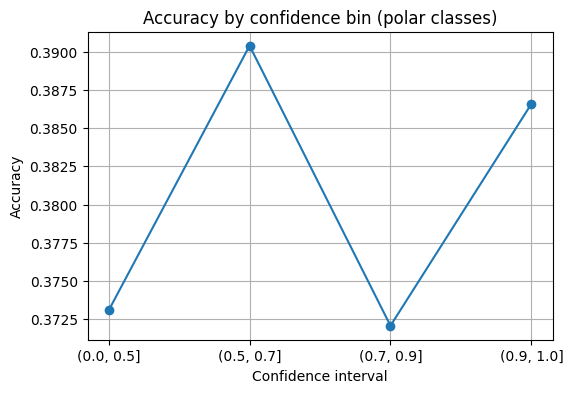

                 time  y_true  y_pred  confidence  y_true_label  y_pred_label
0 2025-12-30 21:00:00       0       0    0.787903             0             0
1 2025-12-30 22:00:00       0       0    0.704435             0             0
2 2025-12-30 23:00:00       0       0    0.515011             0             0
3 2026-01-05 06:00:00       0       0    0.485347             0             0
4 2026-01-05 07:00:00       1       0    0.413959             1             0
                 time  y_true  y_pred  confidence  y_true_label  y_pred_label
0 2026-01-05 13:00:00       2       1    0.435314             2             1
1 2026-01-05 14:00:00       2       1    0.771239             2             1
2 2026-01-05 15:00:00       2       1    0.905965             2             1
3 2026-01-05 16:00:00       2       1    0.949401             2             1
4 2026-01-05 17:00:00       2       1    0.709849             2             1
                 time  y_true  y_pred  confidence  y_true_label 

In [16]:
# ==========================================================
# CONFIG
# ==========================================================


N_BEST = 3
TP_ATR_VALUES = [0.75]
SL_ATR_VALUES = [0.75]

COMISSION_PCT = 0.15

HORIZON_VALUES = [15]
THRESHOLD_VALUES = [0.0075]



cb_conf_threshold = 0.5
nn_conf_threshold = 0.5
USE_TREND_FILTER = True          # оставляем True для подготовки данных (если нужно)
# USE_TREND_FILTER_IN_SIMULATION = False   # ← Новый флаг

SIGNAL_TF_MINUTES = 60

# ==========================================================
# MAIN
# ==========================================================
if __name__ == '__main__':
    params = {
        
        'sma_periods': [3, 7],
        'ema_periods': [3, 7],
        'rsi_period': 4,
        'adx_period': 4,
        'macd_fast': 3,
        'macd_slow': 8,
        'macd_signal': 3,
        'atr_period': 14,
        'bb_period': 5,
        'bb_std': 2,
        'lags': [1, 2, 5, 8, 13],
        'use_trend_filter': False
        
    }
    

    all_sim_results = []
    print("=== Запуск оптимизации параметров ===")

    for h in HORIZON_VALUES:
        for th in THRESHOLD_VALUES:
            print(f"\n{'='*70}")
            print(f"=== TRAINING: horizon={h}, threshold={th*100:.3f}% ===")
            print(f"{'='*70}")

            try:
                # 1. Подготовка данных
                print("[INFO] Preparing data...")
#                 df_train = prepare_data(df_hour_train, df_min_train, df_train_15min, params, params_15min, horizon=h, threshold=th)
#                 df_test = prepare_data(df_hour_test, df_min_test, df_test_15min, params, params_15min, horizon=h, threshold=th)
#                 df_sim = prepare_data(df_hour_sim, df_min_sim, df_sim_15min, params, params_15min, horizon=h, threshold=th)
                
                df_train = prepare_data(df_hour_train, df_min_train, params, horizon=h, threshold=th)
                df_test = prepare_data(df_hour_test, df_min_test, params, horizon=h, threshold=th)
                df_sim = prepare_data(df_hour_sim, df_min_sim, params, horizon=h, threshold=th)
                print(1)

                # Приведение времени
                for df_name in [df_train, df_test, df_sim]:
                    if 'time' in df_name.columns:
                        df_name['time'] = pd.to_datetime(df_name['time'], errors='coerce')
                    df_name.dropna(subset=['time'], inplace=True)
                    df_name.reset_index(drop=True, inplace=True)

                # 2. Feature columns
                feature_cols = [
                    c for c in df_train.columns
                    if c not in ('label', 'time', 'ds', 'minmax_diff')
                    and pd.api.types.is_numeric_dtype(df_train[c])
                ]

                # 3. Тренд-фильтр 4H (только для данных, если нужно)
                if USE_TREND_FILTER:
                    print("[INFO] Adding 4H trend filter...")
                    df_train = add_trend_filter(df_train, timeframe='4h', ema_period=7)
                    df_test = add_trend_filter(df_test, timeframe='4h', ema_period=7)
                    df_sim = add_trend_filter(df_sim, timeframe='4h', ema_period=7)

                # 4. Обучение моделей
                print("[INFO] Training CatBoost...")
                model_cb, class_map_cb, score_cb, *_ = train_and_evaluate(df_train, feature_cols)
                
                model_nn, scaler_nn, metr_nn = train_cnn_bilstm(
                    df_train,
                    feature_cols,
                    target_col='label',
                    seq_len=20,
                    epochs=20,
                    batch_size=128
                )

                # 5. Симуляция
                for tp_atr in TP_ATR_VALUES:
                    for sl_atr in SL_ATR_VALUES:
                        print(f"\n[SIM] h={h} | th={th:.4f} | TP={tp_atr} | SL={sl_atr}")

                        try:
                            horizon_minutes = h * SIGNAL_TF_MINUTES

                            # === CatBoost-only ===
                            print(f"   [CatBoost-only] confidence >= {cb_conf_threshold}")

                            cb_results = evaluate_catboost(
                                model=model_cb,
                                df_test=df_sim.copy(),
                                features=feature_cols,
                                class_map=class_map_cb,
                                params=params,
                                target_classes=[0, 2],
                                plot_confidence=False
                            )
                            
                            nn_results = evaluate_cnn_bilstm(
                                model=model_nn,
                                scaler=scaler_nn,
                                df_test=df_sim.copy(),
                                features=feature_cols,
                                seq_len=10,
                                target_classes=[0, 2]
                            )
                            
                            

                            pred_df = cb_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_df.head())
                            
                            pred_nn = nn_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_nn.head())
                            

                            df_sim_with_signals = df_sim.reset_index(drop=True).merge(
                                pred_df[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )
                            df_sim_with_signals = df_sim_with_signals.rename(columns = {'y_pred' : 'y_pred_cb', 'confidence' : 'confidence_cb'})
                            
                            pred_nn = nn_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_nn.head())
                            
                            df_sim_with_signals =  df_sim_with_signals.merge(
                                pred_nn[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )

                            df_sim_with_signals = df_sim_with_signals.rename(columns = {'y_pred' : 'y_pred_nn', 'confidence' : 'confidence_nn'})

                
                            
                            df_final, trades_df, report = run_simulator(
                                    df_sim_signals=df_sim_with_signals,
                                    df_prices_1m=df_min_sim,
                                    signal_source="ensemble",      # или "cb", "nn"
                                    ensemble_rule="agreement",     # или "confidence", "nn_priority" и т.д.
                                    min_conf_nn=nn_conf_threshold,
                                    min_conf_cb=cb_conf_threshold,
                                    stop_loss_pct=sl_atr,
                                    take_profit_pct=tp_atr,
                                    use_trend_filter=USE_TREND_FILTER,
                                    horizon_minutes=horizon_minutes,
                                    commission_pct=COMISSION_PCT
                                )


                            # Сохранение результатов
                            for r, sim_type in zip([report], ['normal']):
                                all_sim_results.append({
                                    'model': 'CatBoost_only',
                                    'simulation_type': sim_type,
                                    'horizon': h,
                                    'threshold': th,
                                    'tp_atr': tp_atr,
                                    'sl_atr': sl_atr,
                                    'horizon_minutes': horizon_minutes,
                                    'total_trades': r.get('total_trades', 0),
                                    'winrate': r.get('winrate', 0),
                                    'total_pnl_pct': r.get('total_pnl_pct', 0),
                                    'avg_profit_pct': r.get('avg_profit_pct', 0),
                                    'profit_factor': r.get('profit_factor', 0),
                                    'avg_minutes': r.get('avg_minutes', 0),
                                })

                        except Exception as sim_e:
                            print(f"   ❌ SIM ERROR: {sim_e}")
                            continue

            except Exception as e:
                print(f"❌ TRAIN ERROR (h={h}, th={th}): {e}")
                traceback.print_exc()
                continue
                continue

    # ==========================================================
    # ИТОГОВЫЙ РЕЗУЛЬТАТ
    # ==========================================================
    sim_df = pd.DataFrame(all_sim_results)
    if sim_df.empty:
        print("❌ Нет результатов симуляции")
    else:
        sort_cols = ['total_pnl_pct', 'profit_factor', 'winrate']
        sort_cols = [c for c in sort_cols if c in sim_df.columns]
        sim_df = sim_df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

        print("\n" + "="*90)
        print("=== TOP SIMULATION RESULTS ===")
        print("="*90)
        print(sim_df.head(30))

        sim_df.to_csv("simulation_results.csv", index=False)
        print("\n💾 Результаты сохранены: simulation_results.csv")

In [ ]:
# Сохранение датафрейма с прогнозами

In [20]:
# df_train
df_min_train 

,open,close,high,low,value,begin,end,time
0,2804.0,2804.0,2804.0,2804.0,13204036.0,2016-04-29 09:59:00,2016-04-29 09:59:59,2016-04-29 09:59:00
1,2804.5,2804.5,2808.5,2797.0,46255277.5,2016-04-29 10:00:00,2016-04-29 10:00:59,2016-04-29 10:00:00
2,2806.0,2804.5,2808.5,2804.0,11295045.0,2016-04-29 10:01:00,2016-04-29 10:01:59,2016-04-29 10:01:00
3,2804.5,2804.5,2806.0,2804.0,9004086.5,2016-04-29 10:02:00,2016-04-29 10:02:59,2016-04-29 10:02:00
4,2805.5,2806.5,2806.5,2804.0,6411370.0,2016-04-29 10:03:00,2016-04-29 10:03:59,2016-04-29 10:03:00
...,...,...,...,...,...,...,...,...
1709004,5904.5,5904.5,5904.5,5904.0,1434748.5,2025-12-30 20:55:00,2025-12-30 20:55:59,2025-12-30 20:55:00
1709005,5904.0,5903.5,5904.0,5900.0,1540670.5,2025-12-30 20:56:00,2025-12-30 20:56:59,2025-12-30 20:56:00
1709006,5902.5,5902.5,5903.5,5902.0,389588.0,2025-12-30 20:57:00,2025-12-30 20:57:59,2025-12-30 20:57:00
1709007,5902.5,5902.0,5902.5,5902.0,460361.5,2025-12-30 20:58:00,2025-12-30 20:58:59,2025-12-30 20:58:00


# 6.2 Фиксированный процент с тренд-фильтром и мета-моделью

In [ ]:
# ==========================================================
# CONFIG
# ==========================================================

N_BEST = 3
TP_ATR_VALUES = [0.75]
SL_ATR_VALUES = [0.75]

COMISSION_PCT = 0.15

HORIZON_VALUES = [10]
THRESHOLD_VALUES = [0.0075]



cb_conf_threshold = 0.5
nn_conf_threshold = 0.5
USE_TREND_FILTER = True          # оставляем True для подготовки данных (если нужно)
# USE_TREND_FILTER_IN_SIMULATION = False   # ← Новый флаг

SIGNAL_TF_MINUTES = 60

# ==========================================================
# MAIN
# ==========================================================
if __name__ == '__main__':
    params = {
        'sma_periods': [3, 7],
        'ema_periods': [3, 7],
        'rsi_period': 4,
        'adx_period': 4,
        'macd_fast': 3,
        'macd_slow': 8,
        'macd_signal': 3,
        'atr_period': 14,
        'bb_period': 5,
        'bb_std': 2,
        'lags': [1, 2, 5, 8, 13]
    }
    
    params_15min = {
            'rsi_periods': [7, 14],
            'atr_period': 10,
            'use_momentum': True,
            'use_candle_patterns': True
        }

    all_sim_results = []
    print("=== Запуск оптимизации параметров ===")

    for h in HORIZON_VALUES:
        for th in THRESHOLD_VALUES:
            print(f"\n{'='*70}")
            print(f"=== TRAINING: horizon={h}, threshold={th*100:.3f}% ===")
            print(f"{'='*70}")

            try:
                # 1. Подготовка данных
                print("[INFO] Preparing data...")

                
                df_train = prepare_data(df_hour_train, df_min_train, params, horizon=h, threshold=th)
#                 df_test = prepare_data(df_hour_test, df_min_test, params, horizon=h, threshold=th)
                df_sim = prepare_data(df_hour_sim, df_min_sim, params, horizon=h, threshold=th)

                # Приведение времени
                for df_name in [df_train, df_sim]:
                    if 'time' in df_name.columns:
                        df_name['time'] = pd.to_datetime(df_name['time'], errors='coerce')
                    df_name.dropna(subset=['time'], inplace=True)
                    df_name.reset_index(drop=True, inplace=True)

                # 2. Feature columns
                feature_cols = [
                    c for c in df_train.columns
                    if c not in ('label', 'time', 'ds', 'minmax_diff')
                    and pd.api.types.is_numeric_dtype(df_train[c])
                ]
                
                # 3. Meta-модель
                embargo_bars = h * 2 
                
                # 3.1. OOF-сигналы primary-модели
                df_train_oof = get_oof_primary_predictions(
                    df_train, feature_cols, n_splits=5, embargo=embargo_bars
                ).dropna(subset=['oof_pred'])

                # 3.2. Реальный исход каждой OOF-сделки -> мета-метка
                meta_df = build_meta_labels_via_simulation(
                    df_train_oof, df_min_train,
                    simulate_fn=simulate_positions_from_signals_and_minutes,   # ваша функция
                    stop_loss_pct=0.75, take_profit_pct=0.75,
                    horizon_minutes=HORIZON * SIGNAL_TF_MINUTES,
                    commission_pct=COMISSION_PCT,
                )

                # 3.3 Обучение мета-модели
                meta_feature_cols = build_meta_features(meta_df, feature_cols)

                meta_model = train_meta_model(meta_df, meta_feature_cols, embargo=embargo_bars)

                
                

                # 4. Тренд-фильтр 4H (только для данных, если нужно)
                if USE_TREND_FILTER:
                    print("[INFO] Adding 4H trend filter...")
                    df_train = add_trend_filter(df_train, timeframe='4h', ema_period=7)
#                     df_test = add_trend_filter(df_test, timeframe='4h', ema_period=7)
                    df_sim = add_trend_filter(df_sim, timeframe='4h', ema_period=7)

                # 5. Обучение моделей
                print("[INFO] Training CatBoost...")
                model_cb, class_map_cb, score_cb, *_ = train_and_evaluate(df_train, feature_cols)
                
                model_nn, scaler_nn, metr_nn = train_cnn_bilstm(
                    df_train,
                    feature_cols,
                    target_col='label',
                    seq_len=20,
                    epochs=20,
                    batch_size=128
                )

                # 5. Симуляция
                for tp_atr in TP_ATR_VALUES:
                    for sl_atr in SL_ATR_VALUES:
                        print(f"\n[SIM] h={h} | th={th:.4f} | TP={tp_atr} | SL={sl_atr}")

                        try:
                            horizon_minutes = h * SIGNAL_TF_MINUTES

                            # === CatBoost-only ===
                            print(f"   [CatBoost-only] confidence >= {cb_conf_threshold}")

                            cb_results = evaluate_catboost(
                                model=model_cb,
                                df_test=df_sim.copy(),
                                features=feature_cols,
                                class_map=class_map_cb,
                                params=params,
                                target_classes=[0, 2],
                                plot_confidence=False
                            )
                            
                            nn_results = evaluate_cnn_bilstm(
                                model=model_nn,
                                scaler=scaler_nn,
                                df_test=df_sim.copy(),
                                features=feature_cols,
                                seq_len=10,
                                target_classes=[0, 2]
                            )
                            
                            

                            pred_df = cb_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_df.head())
                            
                            pred_nn = nn_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_nn.head())
                            

                            df_sim_with_signals = df_sim.reset_index(drop=True).merge(
                                pred_df[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )
                            df_sim_with_signals = df_sim_with_signals.rename(columns = {'y_pred' : 'y_pred_cb', 'confidence' : 'confidence_cb'})
                            
                            pred_nn = nn_results['predictions_df'].copy().reset_index(drop=True)
                            
                            print(pred_nn.head())
                            
                            df_sim_with_signals =  df_sim_with_signals.merge(
                                pred_nn[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )

                            df_sim_with_signals = df_sim_with_signals.rename(columns = {'y_pred' : 'y_pred_nn', 'confidence' : 'confidence_nn'})

                            
    
                            df_sim_filtered = apply_meta_filter(
                                df_sim_with_signals, meta_model, meta_feature_cols,
                                primary_pred_col='y_pred_cb', primary_conf_col='confidence_cb',
                                meta_threshold=0.55, size_by_meta_proba=True)
        
        
        
                            df_final, trades_df, report = run_simulator(
                                    df_sim_signals=df_sim_filtered,
                                    df_prices_1m=df_min_sim,
                                    signal_source="ensemble",      # или "cb", "nn"
                                    ensemble_rule="agreement",     # или "confidence", "nn_priority" и т.д.
                                    min_conf_nn=nn_conf_threshold,
                                    min_conf_cb=cb_conf_threshold,
                                    stop_loss_pct=sl_atr,
                                    take_profit_pct=tp_atr,
                                    use_trend_filter=USE_TREND_FILTER,
                                    horizon_minutes=horizon_minutes,
                                    commission_pct=COMISSION_PCT
                                )


                            # Сохранение результатов
                            for r, sim_type in zip([report], ['normal']):
                                all_sim_results.append({
                                    'model': 'CatBoost_only',
                                    'simulation_type': sim_type,
                                    'horizon': h,
                                    'threshold': th,
                                    'tp_atr': tp_atr,
                                    'sl_atr': sl_atr,
                                    'horizon_minutes': horizon_minutes,
                                    'total_trades': r.get('total_trades', 0),
                                    'winrate': r.get('winrate', 0),
                                    'total_pnl_pct': r.get('total_pnl_pct', 0),
                                    'avg_profit_pct': r.get('avg_profit_pct', 0),
                                    'profit_factor': r.get('profit_factor', 0),
                                    'avg_minutes': r.get('avg_minutes', 0),
                                })

                        except Exception as sim_e:
                            print(f"   ❌ SIM ERROR: {sim_e}")
                            continue

            except Exception as e:
                print(f"❌ TRAIN ERROR (h={h}, th={th}): {e}")
                continue

    # ==========================================================
    # ИТОГОВЫЙ РЕЗУЛЬТАТ
    # ==========================================================
    sim_df = pd.DataFrame(all_sim_results)
    if sim_df.empty:
        print("❌ Нет результатов симуляции")
    else:
        sort_cols = ['total_pnl_pct', 'profit_factor', 'winrate']
        sort_cols = [c for c in sort_cols if c in sim_df.columns]
        sim_df = sim_df.sort_values(by=sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

        print("\n" + "="*90)
        print("=== TOP SIMULATION RESULTS ===")
        print("="*90)
        print(sim_df.head(30))

        sim_df.to_csv("simulation_results.csv", index=False)
        print("\n💾 Результаты сохранены: simulation_results.csv")

# 6.3 ATR-разметка без мета-модели

# 7. Сохранение моделей

In [ ]:
#cb
import pickle

def save_catboost_package(model, feature_cols, params, save_path):
    """
    Сохраняет CatBoost-модель в формате, совместимом с текущим loaded_models-загрузчиком:
    package['model'], package['feature_cols'], package['params'].
    """
    package = {
        'model': model,
        'feature_cols': feature_cols,   # список имён фич В ТОМ ЖЕ ПОРЯДКЕ, что при обучении
        'params': params,               # словарь параметров пайплайна (индикаторы, use_trend_filter и т.д.)
    }

    with open(save_path, 'wb') as f:
        pickle.dump(package, f)

    print(f"✅ Модель сохранена: {save_path} | Фич: {len(feature_cols)}")
    

params = {
        'sma_periods': [3, 7],
        'ema_periods': [3, 7],
        'rsi_period': 4,
        'adx_period': 4,
        'macd_fast': 3,
        'macd_slow': 8,
        'macd_signal': 3,
        'atr_period': 14,
        'bb_period': 5,
        'bb_std': 2,
        'lags': [1, 2, 5, 8, 13],
        'use_trend_filter': False
        
}

save_catboost_package(
    model=model_cb,
    feature_cols=feature_cols,
    params=params,
    save_path=r"D:\sd\moexalgo\saved_models\lkoh\lkoh_1h_0.75_h15.pkl"
)

In [ ]:
#nn

torch.save({
    "model_state_dict": model_nn.state_dict(),
    "model_config": {"input_size": 32, "hidden_size": 64, "num_layers": 2, "seq_len": 10},
    "scaler": scaler_nn,
    "feature_cols": feature_cols,
}, "nn_lstm_cnn_ag_15.pt")

# 8. Перебор комбинаций

In [ ]:
df_new_sim =  df_sim.reset_index(drop=True).merge(
                                pred_df[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )
df_new_sim = df_new_sim.rename(columns = {'y_pred' : 'y_pred_cb', 'confidence' : 'confidence_cb'})

df_new_sim =  df_new_sim.merge(
                                pred_nn[['time', 'y_pred', 'confidence']],
                                on='time', how='left'
                            )

df_new_sim = df_new_sim.rename(columns = {'y_pred' : 'y_pred_nn', 'confidence' : 'confidence_nn'})

print(df_new_sim.columns)

In [32]:
_, trades_df_3, report_3 = run_simulator(
    df_sim_signals=df_sim_with_signals,
    df_prices_1m=df_min_sim,
    signal_source="nn",      # или "cb", "nn"
    ensemble_rule="agreement",     # или "confidence", "nn_priority" и т.д.
    min_conf_nn=0.0,
    min_conf_cb=0.5,
    stop_loss_pct=0.75,
    take_profit_pct=0.75,
    use_trend_filter=False,
    horizon_minutes=horizon_minutes,
    commission_pct=0.15
)


[INFO] ▶ run_simulator
   Mode          : nn (agreement)
   SL            : 0.75%
   TP            : 0.75%
   Commission    : 0.15%
   Horizon       : 900 min
   Trend Filter  : False
   min_conf_nn   : 0.0
   min_conf_cb   : 0.5
[INFO] Running minute-level simulation...

[INFO] ✔ Simulation finished
   Trades       : 424
   Winrate      : 20.52%
   Total PnL    : -56.08%
   Profit Factor: 0.46
   Max DD       : -3190.83 points


# 9. Визуализация

In [34]:


# ===================== НАСТРОЙКИ КОЛОНОК =====================
# Свечи (df_candles) — должны содержать time/open/high/low/close
# и опционально колонку тренда (например 'trend_4h': 1 / -1 / 0) и EMA
CANDLE_COLS = {
    'time': 'time',
    'open': 'open',
    'high': 'high',
    'low': 'low',
    'close': 'close',
    'trend': 'trend_4h',   # None, если разметки тренда нет
    'ema': 'ema_4',        # None, если EMA не нужна
}

# Сделки (df_trades)
TRADE_COLS = {
    'entry_time': 'open_dt',
    'entry_price': 'open_price',
    'exit_time': 'close_dt',     # можно None, если сделка ещё открыта
    'exit_price': 'exit_price',
    'direction': 'side',         # 'buy'/'sell' или 'long'/'short'
}


def create_combined_trading_chart(df_candles: pd.DataFrame,
                                   df_trades: pd.DataFrame,
                                   output_file: str = "combined_trading_chart.html",
                                   title: str = "Свечи + тренд + сделки",
                                   max_trades: int = 500,
                                   max_points: int = 5000):
    """
    Объединяет:
      - японские свечи
      - фоновую разметку тренда (vrect, агрегированную по блокам, а не по каждой свече)
      - EMA (если есть)
      - маркеры входов в сделки (треугольники вверх/вниз) с подписями LONG/SHORT
      - пунктирные линии от входа к выходу
    в один HTML-файл.
    """

    df_candles = df_candles.copy()
    df_trades = df_trades.copy()

    # ---------- Подготовка свечей ----------
    df_candles[CANDLE_COLS['time']] = pd.to_datetime(df_candles[CANDLE_COLS['time']])
    df_candles = df_candles.sort_values(CANDLE_COLS['time']).reset_index(drop=True)

    if len(df_candles) > max_points:
        step = len(df_candles) // max_points
        print(f"⚠️ Свечи прорежены с {len(df_candles)} до ~{max_points} точек для скорости отображения (шаг {step})")
        df_plot = df_candles.iloc[::step].copy().reset_index(drop=True)
    else:
        df_plot = df_candles.copy()

    # ---------- Подготовка сделок ----------
    for col in ('entry_time', 'exit_time'):
        colname = TRADE_COLS.get(col)
        if colname and colname in df_trades.columns:
            df_trades[colname] = pd.to_datetime(df_trades[colname])

    if len(df_trades) > max_trades:
        print(f"⚠️ Показано только {max_trades} сделок из {len(df_trades)}")
        df_trades = df_trades.iloc[-max_trades:].copy()

    fig = make_subplots(rows=1, cols=1, shared_xaxes=True)

    # ---------- Фоновая разметка тренда (рисуется первой, чтобы быть под свечами) ----------
    trend_col = CANDLE_COLS.get('trend')
    if trend_col and trend_col in df_plot.columns:
        # Принудительно приводим к числу — если колонка была object/category,
        # .diff() на ней либо падает, либо не находит изменений, и разметка молча не рисуется.
        trend_series = pd.to_numeric(df_plot[trend_col], errors='coerce').round()

        print(f"[trend debug] dtype до приведения: {df_plot[trend_col].dtype}")
        print(f"[trend debug] уникальные значения: {trend_series.value_counts(dropna=False).to_dict()}")

        # NaN оставляем как отдельное "нейтральное" состояние, а не роняем строки,
        # чтобы не сбить индексацию относительно df_plot[CANDLE_COLS['time']]
        change_mask = trend_series.diff().fillna(1) != 0  # первая строка всегда считается началом блока
        changes = df_plot.index[change_mask].tolist()
        changes = sorted(set([0] + changes + [len(df_plot) - 1]))

        print(f"[trend debug] найдено блоков тренда: {len(changes) - 1}")

        # Вместо поштучных fig.add_vrect() (в связке с make_subplots иногда не долетают
        # до layout.shapes при сериализации) — собираем все прямоугольники как обычные
        # dict-объекты и присваиваем их ОДНИМ пакетным update_layout(shapes=[...]).
        shape_list = []
        for i in range(len(changes) - 1):
            start_idx = changes[i]
            end_idx = changes[i + 1]
            if start_idx == end_idx:
                continue
            trend_val = trend_series.iloc[start_idx]

            if trend_val == 1:
                color = 'rgba(0, 255, 120, 0.18)'
            elif trend_val == -1:
                color = 'rgba(255, 60, 60, 0.18)'
            else:
                color = 'rgba(150, 150, 150, 0.10)'

            shape_list.append(dict(
                type="rect",
                xref="x",
                yref="y domain",
                x0=df_plot[CANDLE_COLS['time']].iloc[start_idx],
                x1=df_plot[CANDLE_COLS['time']].iloc[end_idx],
                y0=0,
                y1=1,
                fillcolor=color,
                opacity=1,
                layer="below",
                line_width=0,
            ))

        fig.update_layout(shapes=shape_list)
        print(f"[trend debug] прямоугольников подготовлено: {len(shape_list)}")

    else:
        print(f"[trend debug] колонка тренда '{trend_col}' не найдена в df_plot.columns — фон не рисуется")

    # ---------- Свечи ----------
    fig.add_trace(
        go.Candlestick(
            x=df_plot[CANDLE_COLS['time']],
            open=df_plot[CANDLE_COLS['open']],
            high=df_plot[CANDLE_COLS['high']],
            low=df_plot[CANDLE_COLS['low']],
            close=df_plot[CANDLE_COLS['close']],
            name="Свечи",
            increasing_line_color='#26A69A',
            decreasing_line_color='#EF5350',
        )
    )

    # ---------- EMA ----------
    ema_col = CANDLE_COLS.get('ema')
    if ema_col and ema_col in df_plot.columns:
        fig.add_trace(
            go.Scatter(
                x=df_plot[CANDLE_COLS['time']],
                y=df_plot[ema_col],
                name="EMA",
                line=dict(color='orange', width=2.5, dash='dash'),
            )
        )

    # ---------- Сделки: маркеры входов + линии вход->выход ----------
    entry_times, entry_prices, entry_texts, entry_colors, entry_symbols = [], [], [], [], []
    line_x, line_y = [], []

    for _, trade in df_trades.iterrows():
        direction = trade.get(TRADE_COLS['direction'], 'buy')
        is_long = direction in ('buy', 'long', 1)
        color = '#00FF88' if is_long else '#FF3366'
        symbol = 'triangle-up' if is_long else 'triangle-down'

        entry_time = trade[TRADE_COLS['entry_time']]
        entry_price = trade[TRADE_COLS['entry_price']]

        entry_times.append(entry_time)
        entry_prices.append(entry_price)
        entry_texts.append('LONG' if is_long else 'SHORT')
        entry_colors.append(color)
        entry_symbols.append(symbol)

        exit_time_col = TRADE_COLS.get('exit_time')
        if exit_time_col and pd.notna(trade.get(exit_time_col)):
            exit_time = trade[exit_time_col]
            exit_price = trade.get(TRADE_COLS['exit_price'])
            line_x.extend([entry_time, exit_time, None])
            line_y.extend([entry_price, exit_price, None])

    if entry_times:
        fig.add_trace(
            go.Scatter(
                x=entry_times,
                y=entry_prices,
                mode='markers+text',
                name='Сделки',
                marker=dict(symbol=entry_symbols, size=14, color=entry_colors,
                            line=dict(width=2, color='black')),
                text=entry_texts,
                textposition="top center",
                hovertemplate="%{text}<br>Время: %{x}<br>Цена: %{y}<extra></extra>",
            )
        )

    if line_x:
        fig.add_trace(
            go.Scatter(
                x=line_x,
                y=line_y,
                mode='lines',
                name='Путь сделки',
                line=dict(width=2, dash='dot', color='white'),
                hoverinfo='skip',
            )
        )

    # ---------- Оформление ----------
    fig.update_layout(
        title=title,
        xaxis_title="Время",
        yaxis_title="Цена",
        xaxis_rangeslider_visible=False,
        height=800,
        template="plotly_dark",
        hovermode="x unified",
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(t=60, b=50, l=50, r=30),
    )

    fig.update_yaxes(autorange=True, rangemode='normal', automargin=True)
    fig.update_xaxes(rangeslider=dict(visible=False), autorange=True)

    print(f"[trend debug] shapes в fig.layout непосредственно перед сохранением: {len(fig.layout.shapes)}")

    fig.write_html(
        output_file,
        include_plotlyjs='cdn',
        full_html=True,
        config={
            'scrollZoom': True,
            'modeBarButtonsToRemove': ['lasso2d', 'select2d'],
            'responsive': True,
        },
    )

    print(f"✅ Объединённый HTML-график создан: {output_file}")
    return fig


In [35]:
create_combined_trading_chart(df_sim_with_signals, 
                             trades_df_3, output_file = "ctc_lkoh_nn_1309.html")

[trend debug] dtype до приведения: float64
[trend debug] уникальные значения: {-1.0: 1205, 1.0: 843, 0.0: 163, nan: 3}
[trend debug] найдено блоков тренда: 108
[trend debug] прямоугольников подготовлено: 108
[trend debug] shapes в fig.layout непосредственно перед сохранением: 108
✅ Объединённый HTML-график создан: ctc_lkoh_nn_1309.html
